In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler


In [3]:
data_1 = pd.read_csv("C:/Users/allan/Desktop/IA/ecole/PRED/csv-daily-data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
data_2 = pd.read_csv("C:/Users/allan/Desktop/IA/ecole/PRED/csv-daily-data/2023-02-12.csv")

In [8]:
# Data Preparation

data_1.columns = data_1.columns.str.replace(" ", "").str.lower()
data_2.columns = data_2.columns.str.replace(" ", "").str.lower()

common_columns = list(set(data_1.columns) & set(data_2.columns))

data_1 = data_1[common_columns]
data_2 = data_2[common_columns]

concatenated_data = pd.concat([data_1, data_2], ignore_index=True)

concatenated_data["label_ml"] = (concatenated_data["label"] != "BENIGN").astype(int)
concatenated_data["label_dl"]  = concatenated_data["label"]
concatenated_data = concatenated_data.drop(columns=["label"])


concatenated_data.replace([np.inf, -np.inf], np.nan, inplace=True)
concatenated_data.dropna(inplace=True)


In [9]:
X = concatenated_data.drop(['label_dl', 'label_ml'], axis=1)
y = concatenated_data['label_ml']

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 🔍 Prédictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

Accuracy: 0.9854358747860652
Precision: 0.9854221182839427
Recall: 0.9854358747860652
F1-score: 0.98541465629056
Confusion Matrix:
[[28477   821]
 [  498 60769]]


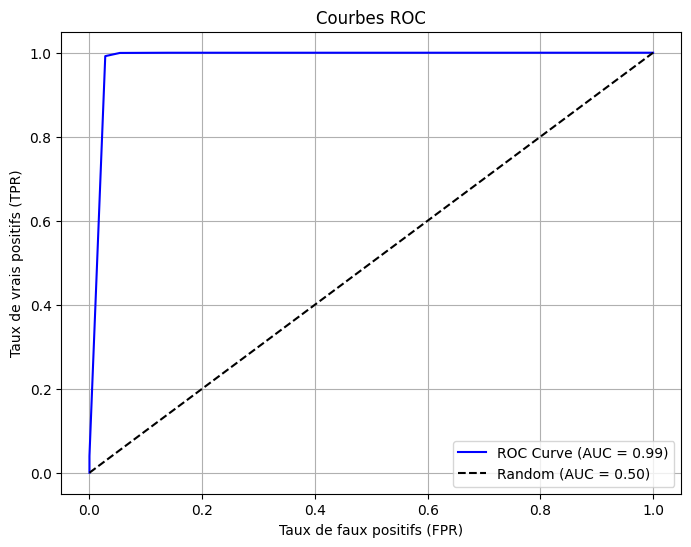

(0.9854358747860652,
 0.9854221182839427,
 0.9854358747860652,
 0.98541465629056,
 array([[28477,   821],
        [  498, 60769]], dtype=int64),
 1.0)

In [12]:
import sys
sys.path.append("eval.py") 
from eval import notation

notation(X_test, y_test, y_pred, model) 